In [32]:
import pandas as pd
from pipeline.preprocess_clinical import load_raw as load_clinical_raw, clean as clean_clinical
from pipeline.preprocess_mrna import load_raw as load_mrna_raw, clean as clean_mrna
from pipeline.run_roma import intersect_samples, test_stage_association
from romapy import ROMA, load_gmt

In [33]:
clinical_raw = load_clinical_raw("data/raw/gsea_clinical.tsv")
clinical_clean = clean_clinical(clinical_raw)
clinical_clean.head()

[preprocess_clinical] skipping imputation for American Joint Committee on Cancer Tumor Stage Code: F1=0.21 < 0.6
[preprocess_clinical] skipping imputation for Neoplasm Disease Lymph Node Stage American Joint Committee on Cancer Code: F1=0.53 < 0.6
[preprocess_clinical] skipping imputation for American Joint Committee on Cancer Metastasis Stage Code: F1=0.53 < 0.6
[preprocess_clinical] dropped 54 of 566 samples with no usable stage label


,Diagnosis Age,Sex,Neoplasm Disease Stage American Joint Committee on Cancer Code,American Joint Committee on Cancer Tumor Stage Code,Neoplasm Disease Lymph Node Stage American Joint Committee on Cancer Code,American Joint Committee on Cancer Metastasis Stage Code,Aneuploidy Score,Mutation Count,Fraction Genome Altered,C_STAGE
Sample ID,,,,,,,,,,
TCGA-05-4244-01,70.0,Male,STAGE IV,T2,N2,M1,17.0,192.0,0.4565,IV
TCGA-05-4249-01,67.0,Male,STAGE IB,T2,N0,M0,24.0,300.0,0.2221,IB
TCGA-05-4250-01,79.0,Female,STAGE IIIA,T3,N1,M0,17.0,312.0,0.2362,IIIA
TCGA-05-4382-01,68.0,Male,STAGE IB,T2,N0,M0,22.0,1547.0,0.0854,IB
TCGA-05-4384-01,66.0,Male,STAGE IIIA,T2,N2,M0,1.0,117.0,0.0661,IIIA


In [34]:
mrna_raw = load_mrna_raw("data/raw/gsea_mrna.txt")
mrna_clean = clean_mrna(mrna_raw)
mrna_clean.shape

[preprocess_mrna] skew: mean=0.42, max=21.40
[preprocess_mrna] kurtosis: mean=3.26, max=471.89


(7397, 510)

[run_roma] dropping 4 clinical-only and 2 expression-only samples; 508 samples in common


<Axes: xlabel='C_STAGE'>

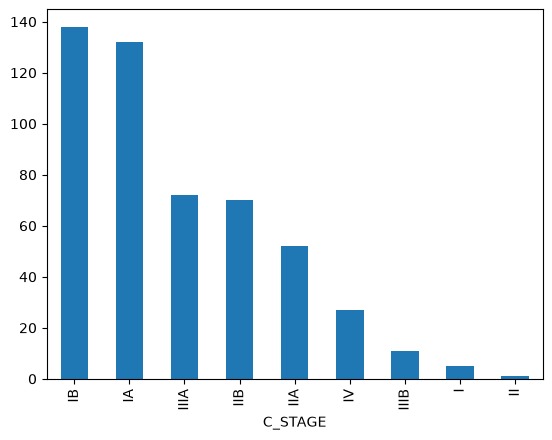

In [35]:
clinical_clean, mrna_clean = intersect_samples(clinical_clean, mrna_clean)
clinical_clean["C_STAGE"].value_counts().plot(kind="bar")

In [40]:
import time
small_gene_sets = {k: v for k, v in list(gene_sets.items())[:2]}

start = time.time()
roma = ROMA(center="fixed", robust=False, n_permutations=200, random_state=0)
results = roma.fit(mrna_clean, small_gene_sets)
print(f"2 modules took {time.time() - start:.1f} seconds")

2 modules took 27.3 seconds


In [41]:
sig = results.significant(alpha=0.05)
sig

,l1,l1_pval,coord
HALLMARK_ADIPOGENESIS,0.132442,0.0,0.12
HALLMARK_ALLOGRAFT_REJECTION,0.309108,0.0,0.00


In [42]:
stage_assoc = test_stage_association(results, clinical_clean)
stage_assoc.head(10)

,f_stat,stage_anova_pval
module,,
HALLMARK_ALLOGRAFT_REJECTION,2.764568,0.007938
HALLMARK_ADIPOGENESIS,0.533561,0.809232


<Axes: title={'center': 'score'}, xlabel='stage'>

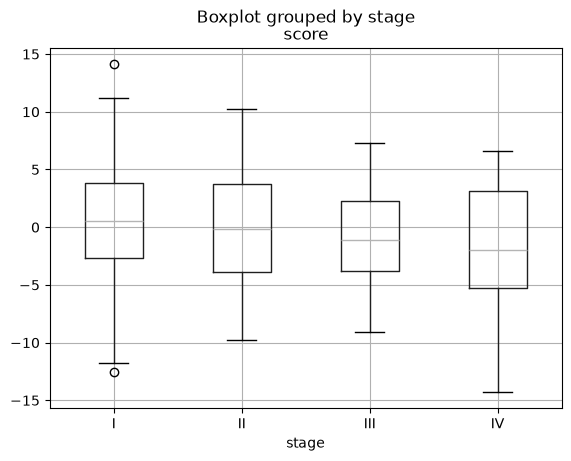

In [44]:
top_module = stage_assoc.index[0]
clinical_clean["C_STAGE_BROAD"] = clinical_clean["C_STAGE"].str.extract(r"(IV|III|II|I)")[0]
merged = pd.DataFrame({"score": results.scores.loc[top_module], "stage": clinical_clean["C_STAGE_BROAD"]})
merged.boxplot(column="score", by="stage")